#### Implementing the simple chatbot using langgraph

In [42]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Reducers

from typing import Annotated
from langgraph.graph.message import add_messages

In [43]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [44]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

In [45]:
from langchain_groq import ChatGroq
model = ChatGroq(model = "llama-3.1-8b-instant", api_key=groq_api_key)
message = model.invoke("What is my name")
print(message.content)

I don't have any information about your name. I'm a conversational AI, and our conversation just started. You haven't told me your name yet. Please feel free to share your name with me if you'd like to!


#### we will start with creating nodes

In [46]:
def superbot(state:State):
    return{"messages":[model.invoke(state['messages'])]}

In [47]:
# Building the graph
graph = StateGraph(State)

graph.add_node("superbot",superbot)
# add edges 
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)


# compile the graph
graph_builder = graph.compile()

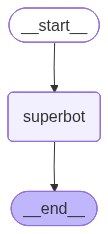

In [48]:
from IPython.display import display, Image
graph_visulaize = graph_builder.get_graph().draw_mermaid_png()
display(Image(graph_visulaize))

In [49]:
## Invocation
graph_builder.invoke({"messages": "Hi, My name is Alok Goyal"})

{'messages': [HumanMessage(content='Hi, My name is Alok Goyal', additional_kwargs={}, response_metadata={}, id='c2e580d2-fda5-4f76-a403-e946276ffca3'),
  AIMessage(content="Hello Alok Goyal, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 44, 'total_tokens': 73, 'completion_time': 0.076985931, 'completion_tokens_details': None, 'prompt_time': 0.003689508, 'prompt_tokens_details': None, 'queue_time': 0.047089372, 'total_time': 0.080675439}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c6cdb-e6f5-7e20-8489-dc94e7d9382e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 29, 'total_tokens': 73})]}

#### Streaming

In [50]:
for event in graph_builder.stream({"messages": "Hi, My name is Alok Goyal"},stream_mode="updates"):
    print(event)

{'superbot': {'messages': [AIMessage(content='Nice to meet you, Alok Goyal. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 44, 'total_tokens': 70, 'completion_time': 0.036575322, 'completion_tokens_details': None, 'prompt_time': 0.002077922, 'prompt_tokens_details': None, 'queue_time': 0.051930017, 'total_time': 0.038653244}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c6cdb-e7fd-7bb0-aeea-c2ae93f19303-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 26, 'total_tokens': 70})]}}


In [51]:
from typing_extensions import TypedDict
from typing import Literal

class Typedictstate(TypedDict):
    name:str
    game:Literal["cricket","badminton"]

In [52]:
def play_game(state:Typedictstate):
    print("---play game node has been called---")
    return {"name" : state["name"] + " wants to play "}

def cricket(state:Typedictstate):
    print("---cricket node has been called---")
    return {"game":"cricket"}

def badminton(state:Typedictstate):
    print("---badminton node has been called---")
    return {"game":"badminton"}

In [53]:
from random import random
def decide_play(state:Typedictstate)->Literal["cricket","badminton"]:
    print("---decide play node has been called---")
    if random.random() > 0.5:
        return "cricket"
    else:
        return "badminton"

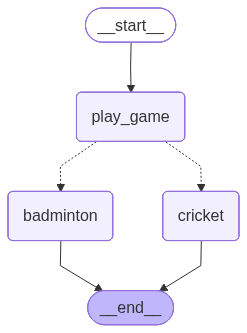

In [54]:
import random
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

graph = StateGraph(Typedictstate)

graph.add_node("play_game",play_game)
graph.add_node("cricket", cricket)
graph.add_node("badminton", badminton)

# flow of the graph
graph.add_edge(START, "play_game")
graph.add_conditional_edges("play_game",decide_play)
graph.add_edge("cricket", END)
graph.add_edge("badminton", END)

graph_builder = graph.compile()
visualise_graph = graph_builder.get_graph().draw_mermaid_png()
display(Image(visualise_graph))


In [55]:
graph_builder.invoke({"name" : "Alok"})

---play game node has been called---
---decide play node has been called---
---badminton node has been called---


{'name': 'Alok wants to play ', 'game': 'badminton'}

In [56]:
# python dataclasses
from dataclasses import dataclass
@dataclass
class dataclassstate:
    name:str
    game:Literal["cricket","badminton"]

In [57]:
def play_game(state:dataclassstate)->dataclassstate:
    print("---play node has been called---")
    return {"name":state.name + " wants to play"}

def cricket(state:dataclassstate):
    print("---cricket node has been called---")
    return {"game" : "cricket"}

def badminton(state:dataclassstate):
    print("---badminton node has been called---")
    return {"game" : "badminton"}

In [58]:
def decide_game(state:dataclassstate)->Literal["cricket","badminton"]:
    print("---decide game node has been called---")
    if random.random() > 0.5:
        return "cricket"
    else:
        return "badminton"

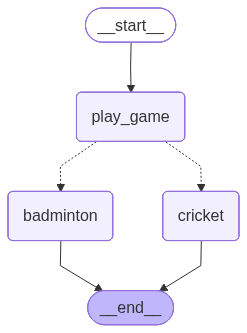

In [59]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

graph = StateGraph(dataclassstate)

# adding nodes
graph.add_node("play_game", play_game)
graph.add_node("cricket",cricket)
graph.add_node("badminton",badminton)

# add edges
graph.add_edge(START,"play_game")
graph.add_conditional_edges("play_game",decide_game)
graph.add_edge("cricket",END)
graph.add_edge("badminton",END)


# compile the graph

graph_builder1 = graph.compile()
visualise_graph1 = graph_builder1.get_graph().draw_mermaid_png()
display(Image(visualise_graph1))

In [60]:
graph_builder1.invoke(dataclassstate(name="Alok", game="cricket"))

---play node has been called---
---decide game node has been called---
---badminton node has been called---


{'name': 'Alok wants to play', 'game': 'badminton'}

#### pydantic data validation

In [61]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel

In [62]:
class State(BaseModel):
    name:str
    

In [63]:
def example_node(state:State):
    return {"name":"hello"}

In [65]:
builder = StateGraph(State)
builder.add_node("example_node",example_node)
builder.add_edge(START,"example_node")
builder.add_edge("example_node",END)

graph_builder = builder.compile()


In [67]:
graph_builder.invoke({"name":11})

ValidationError: 1 validation error for State
name
  Input should be a valid string [type=string_type, input_value=11, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type

================================== Ai Message ==================================

Hello, Please tell me how can I help?
================================ Human Message =================================

I want to learn coding
================================== Ai Message ==================================

Sure, I can help you with that. What programming language are you interested in?
